# Lesson 1 - What does `c` actually do in a Julia set?

A Julia set looks chaotic. It isn't. Every pixel comes from the same
two operations, applied over and over: **square**, then **add c**.

Change `c` and the picture changes - sometimes subtly, sometimes
catastrophically. This notebook is about what that one number does,
and how it turns into the picture you're about to see.

## The rule

Pick a complex number `z`. Apply this to it, forever:

    z  ->  z^2 + c

Three things happen:

1. Square `z`.
2. Add `c` - a constant **you** choose.
3. Repeat with the result.

The **Julia set** for `c` is the set of starting `z` values whose
orbit *stays small forever*. That's the whole definition.

## Iterate by hand at one point

`c = -0.4 + 0.6i`. Start at `z = 0.5 + 0.5i`. Watch what the orbit does.

In [1]:
c = complex(-0.4, 0.6)
z = complex(0.5, 0.5)

print(f"start: z = {z.real:+.4f} {z.imag:+.4f}i")
for n in range(1, 9):
    z = z * z + c
    print(f"  n={n}   z = {z.real:+.4f} {z.imag:+.4f}i   |z| = {abs(z):.4f}")

start: z = +0.5000 +0.5000i
  n=1   z = -0.4000 +1.1000i   |z| = 1.1705
  n=2   z = -1.4500 -0.2800i   |z| = 1.4768
  n=3   z = +1.6241 +1.4120i   |z| = 2.1521
  n=4   z = +0.2440 +5.1865i   |z| = 5.1922
  n=5   z = -27.2398 +3.1305i   |z| = 27.4191
  n=6   z = +731.8084 -169.9510i   |z| = 751.2834
  n=7   z = +506659.7230 -248742.5110i   |z| = 564426.1791
  n=8   z = +194831238096.9879 -252055623444.5376i   |z| = 318576911668.7833


`|z|` is growing. Fast. This `z` is **not** in the Julia set - left
running, its orbit flies off to infinity.

## The other fate - same `c`, different `z`

Same rule. Same `c`. Different starting point.

In [2]:
def iterate(z0, c, n=15):
    z = z0
    print(f"start: z = {z0.real:+.4f} {z0.imag:+.4f}i")
    for k in range(1, n + 1):
        z = z * z + c
        if k <= 3 or k == n:
            print(f"  n={k:2d}   z = {z.real:+.4f} {z.imag:+.4f}i   |z| = {abs(z):.4f}")
    print()


iterate(complex( 0.5, 0.5), c)   # escapes
iterate(complex(-0.5, 0.0), c)   # stays bounded
iterate(complex( 0.0, 0.0), c)   # the critical point

start: z = +0.5000 +0.5000i
  n= 1   z = -0.4000 +1.1000i   |z| = 1.1705
  n= 2   z = -1.4500 -0.2800i   |z| = 1.4768
  n= 3   z = +1.6241 +1.4120i   |z| = 2.1521
  n=15   z = +inf +nani   |z| = inf

start: z = -0.5000 +0.0000i
  n= 1   z = -0.1500 +0.6000i   |z| = 0.6185
  n= 2   z = -0.7375 +0.4200i   |z| = 0.8487
  n= 3   z = -0.0325 -0.0195i   |z| = 0.0379
  n=15   z = -0.7608 +0.5572i   |z| = 0.9430

start: z = +0.0000 +0.0000i
  n= 1   z = -0.4000 +0.6000i   |z| = 0.7211
  n= 2   z = -0.6000 +0.1200i   |z| = 0.6119
  n= 3   z = -0.0544 +0.4560i   |z| = 0.4592
  n=15   z = -0.6390 +0.0196i   |z| = 0.6393



Two points, same rule, opposite outcomes:

- `z = 0.5 + 0.5i` diverges. **Not** in the Julia set.
- `z = -0.5 + 0i` doesn't. **In** the Julia set.
- The orbit of `z = 0` is special - the **critical orbit** - and it
  determines the whole structure.

So "is `z` in the Julia set?" is answered by running the iteration
for a while and watching `|z|`.

## From one point to a picture

To draw the Julia set, do this for **every pixel**:

1. Map the pixel to a complex number `z`.
2. Iterate `z -> z^2 + c` up to `max_iter` times.
3. If `|z|` ever exceeds a **bailout radius** (usually 2), stop early.
4. Record how many iterations it took to escape.

The recorded count is the pixel's value. Pixels that never escaped
get the maximum. Handing that grid of integers to `imshow` with a
colormap *is* the fractal image - there is no separate "draw the
fractal" step.

## The algorithm, spelled out for one point

No NumPy yet. Just the plain scalar loop:

In [3]:
def escape_time(z0, c, max_iter=100, bailout=2.0):
    z = z0
    for n in range(max_iter):
        if abs(z) > bailout:
            return n
        z = z * z + c
    return max_iter


for z0 in [complex(0, 0), complex(0.5, 0.5), complex(-0.5, 0),
           complex(0.1, 0.1), complex(1.0, 1.0)]:
    n = escape_time(z0, c, max_iter=100)
    tag = "bounded" if n == 100 else f"escaped at n={n}"
    print(f"  z0 = {z0.real:+.2f}{z0.imag:+.2f}i   -> {tag}")

  z0 = +0.00+0.00i   -> escaped at n=26
  z0 = +0.50+0.50i   -> escaped at n=3
  z0 = -0.50+0.00i   -> escaped at n=29
  z0 = +0.10+0.10i   -> escaped at n=18
  z0 = +1.00+1.00i   -> escaped at n=1


## The same thing, vectorized

The scalar loop is clear but slow - one point at a time. The actual
`fractal_lab.render.julia` does the same thing to a whole grid with
NumPy. Here's the compact version:

In [4]:
import numpy as np


def julia_grid(c, width=400, height=400, max_iter=100, bailout=2.0):
    x = np.linspace(-2, 2, width)
    y = np.linspace(-2, 2, height)
    Z = x[np.newaxis, :] + 1j * y[:, np.newaxis]
    div = np.zeros(Z.shape, dtype=int)

    for i in range(max_iter):
        mask = np.abs(Z) <= bailout
        if not mask.any():
            break
        Z[mask] = Z[mask] ** 2 + c
        div[mask] = i

    return div


grid = julia_grid(complex(-0.4, 0.6), width=200, height=200)
print("shape:", grid.shape)
print("range:", grid.min(), "to", grid.max())
print("unique values:", np.unique(grid).size)

shape: (200, 200)
range: 0 to 99
unique values: 100


Every number in `grid` is "iterations until escape." That's the raw
data of the image. Rendering is just coloring it in.

## Rendering - the final step

`imshow` maps each integer in `grid` to a color through a colormap.
Low values (escaped fast) go to one end of the map. High values
(escaped slowly or never) go to the other end.

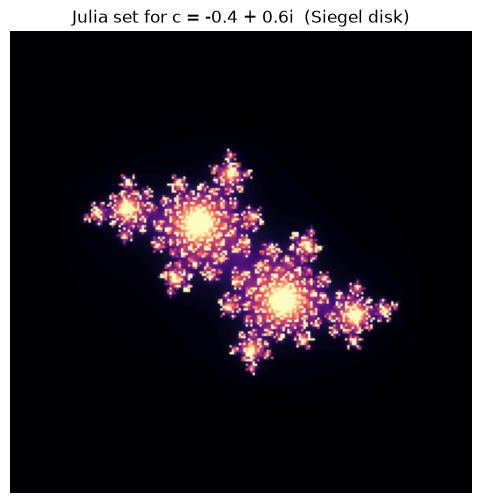

In [5]:
import matplotlib.pyplot as plt
from fractal_lab.palettes import JULIA_CMAP

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(grid, cmap=JULIA_CMAP, extent=[-2, 2, -2, 2], origin="lower")
ax.set_title("Julia set for c = -0.4 + 0.6i  (Siegel disk)")
ax.axis("off")
plt.show()

The whole pipeline, one line:

> **iterate** -> **count escapes** -> **color by count** -> **picture**

Everything below is a variation on that theme.

## Now drag the sliders

The widget below runs the same pipeline on every slider change.
Watch what happens to the picture as `c` moves.

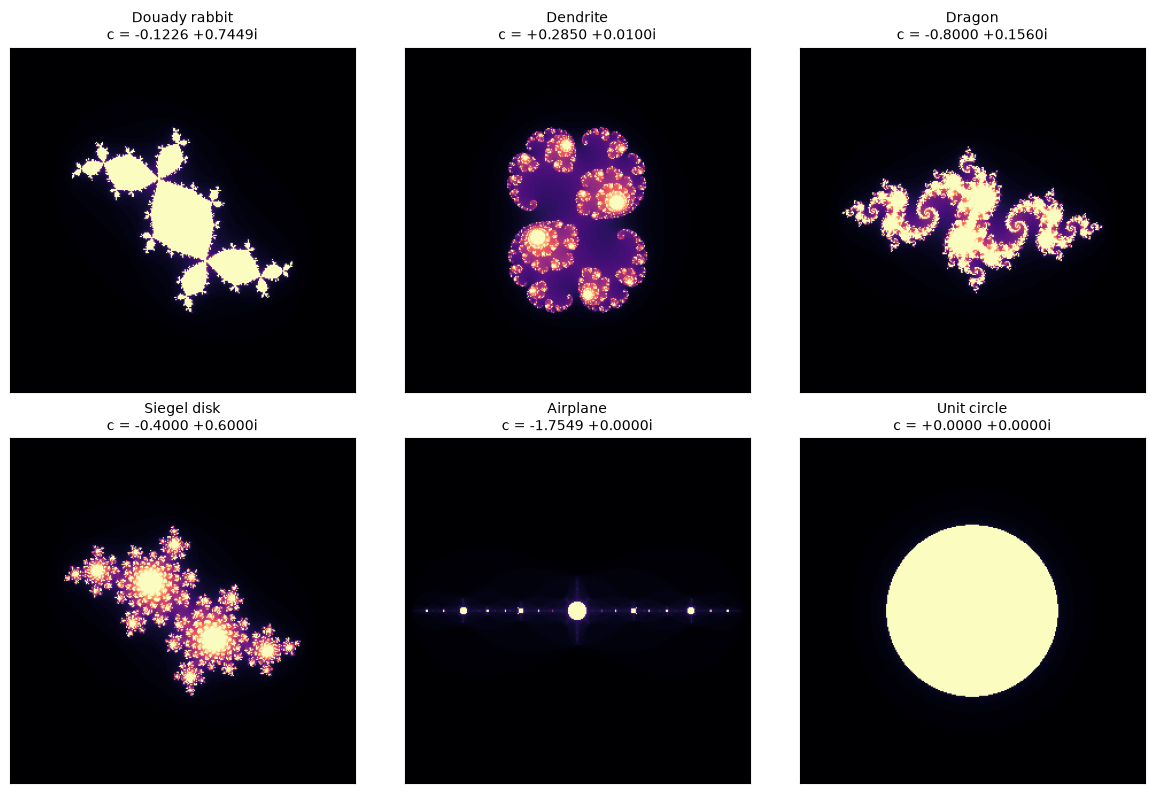

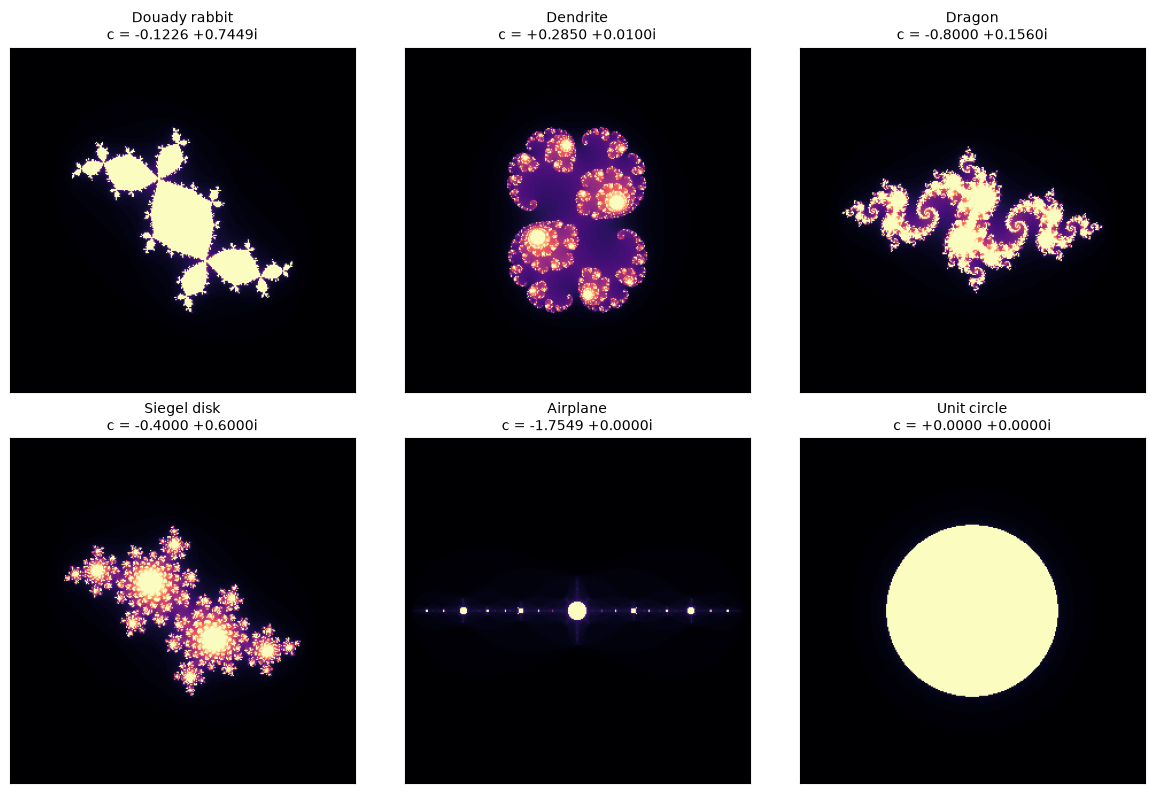

In [6]:
from fractal_lab import lessons
lessons.julia_explorer()

## Reading the widget

- **Re(c)** and **Im(c)** - the real and imaginary parts of `c`.
- **Title** - announces whether the current `c` is **inside** or
  **outside** the Mandelbrot set. Inside -> connected Julia set.
  Outside -> "dust."

## Named examples

Some `c` values have names because they're *structurally* distinct,
not just visually different:

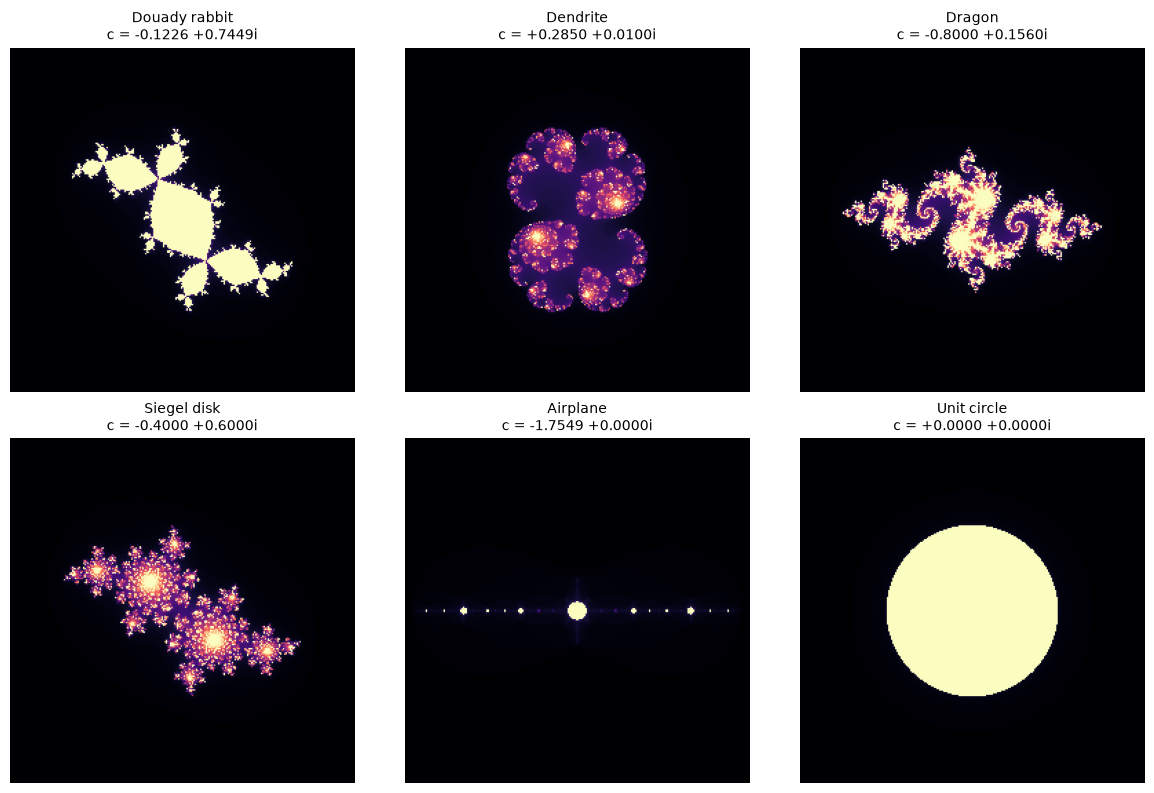

In [7]:
from fractal_lab.render import julia

famous = [
    (complex(-0.122561, 0.744862), "Douady rabbit"),
    (complex( 0.285,   0.010), "Dendrite"),
    (complex(-0.8,     0.156), "Dragon"),
    (complex(-0.4,     0.600), "Siegel disk"),
    (complex(-1.75488, 0.0),   "Airplane"),
    (complex( 0.0,     0.0),   "Unit circle"),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (ci, name) in zip(axes.ravel(), famous):
    div = julia(ci, width=250, height=250, max_iter=120)
    ax.imshow(div, cmap=JULIA_CMAP, extent=[-2, 2, -2, 2], origin="lower")
    ax.set_title(f"{name}\nc = {ci.real:+.4f} {ci.imag:+.4f}i", fontsize=10)
    ax.axis("off")
fig.tight_layout()
plt.show()

## What's next

You now have the whole pipeline: **square, add c, count escapes,
color by count.**

What's still hiding in plain sight is *where `c` lives*. `z` lives
in one plane. `c` lives in another. That's the subject of the next
lesson.